# SE4050 Deep Learning Assignment - Human Activity Recognition (HAR)
## Component 3: Bidirectional LSTM + Shared UCI HAR Data Loader

**Author:** Member 3
**Component:** Stacked Bidirectional LSTM for multi-channel sensor time-series
**Framework:** TensorFlow / Keras (trained from scratch)

This notebook uses the reusable modules in `src/` and does not re-implement them:
- `src/data/uci_har_loader.py` builds the shared, subject-split, train-standardized dataset
- `src/models/bilstm.py` holds the model builder
- `src/train_bilstm.py` holds the training pipeline (callbacks and run logging)

**Rule followed throughout:** the test split is used **once**, in Section 6, with the model chosen in Section 5. All tuning and model selection use the validation split only.

### 1. Setup: imports, seeds, repo path
In Colab, add a `GH_TOKEN` secret (key icon in the sidebar) before running this. The token is never written in a cell. Locally, the cell finds the repo root automatically.

In [1]:
import os
import sys
import json
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import userdata
    TOKEN = userdata.get("GH_TOKEN")
    REPO = "DharanaT567-del/Deep-Learning-Assignment-SE4050"
    BRANCH = "feature-BiLSTM-implement"
    if not Path("/content/repo").exists():
        os.system(f"git clone --branch {BRANCH} https://{TOKEN}@github.com/{REPO}.git /content/repo")
    os.chdir("/content/repo")
    os.system("pip install -q -r requirements.txt")
else:
    # Walk up from the notebook folder until the repo root is found
    root = Path.cwd()
    while not (root / "src" / "data_contract.py").exists() and root != root.parent:
        root = root.parent
    os.chdir(root)

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print("Project root:", PROJECT_ROOT)

Project root: D:\My_ projects\Deep-Learning-Assignment-SE4050


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

from src.data_contract import ACTIVITY_LABEL_MAPPING, load_har_npz, validate_har_dataset
from src.data.uci_har_loader import (
    DEFAULT_OUTPUT_PATH,
    build_processed_dataset,
    download_uci_har,
    print_dataset_summary,
    save_processed_dataset,
)
from src.models.bilstm import build_bilstm_model, load_bilstm_model, predict_bilstm
from src.train_bilstm import load_config, set_seed, train_bilstm_pipeline

SEED = 42
set_seed(SEED)
CLASS_NAMES = [ACTIVITY_LABEL_MAPPING[i] for i in range(6)]

print("TensorFlow:", tf.__version__, "| Keras:", keras.__version__)
print("GPU:", tf.config.list_physical_devices("GPU") or "none (CPU)")

TensorFlow: 2.21.0 | Keras: 3.15.1


GPU: none (CPU)


### 2. Load the data with the shared loader
If `data/uci_har_processed.npz` is missing, it is built from the raw dataset (downloaded first if needed). The printed subject lists are the audit trail: no subject appears in more than one split.

In [3]:
NPZ_PATH = DEFAULT_OUTPUT_PATH

if not NPZ_PATH.exists():
    dataset_dir = download_uci_har()
    save_processed_dataset(build_processed_dataset(dataset_dir, n_val_subjects=4, seed=SEED), NPZ_PATH)

data = load_har_npz(str(NPZ_PATH))            # already standardized with train statistics
validate_har_dataset(data, check_test=True)   # raises on shape, label or subject-leakage problems
print_dataset_summary(data)


[Summary] Array shapes:
  X_train        (5952, 128, 9)  float32
  y_train        (5952,)  int64
  subject_train  (5952,)  int64
  X_val          (1400, 128, 9)  float32
  y_val          (1400,)  int64
  subject_val    (1400,)  int64
  X_test         (2947, 128, 9)  float32
  y_test         (2947,)  int64
  subject_test   (2947,)  int64

[Summary] Subjects per split:
  train (17 subjects): [1, 5, 6, 7, 8, 11, 14, 15, 17, 19, 21, 25, 26, 27, 28, 29, 30]
  val   ( 4 subjects): [3, 16, 22, 23]
  test  ( 9 subjects): [2, 4, 9, 10, 12, 13, 18, 20, 24]
  overlap train/val  none
  overlap train/test none
  overlap val/test   none

[Summary] Class counts per split:
  class                    train     val    test
  0 WALKING                 1012     214     496
  1 WALKING_UPSTAIRS         870     203     471
  2 WALKING_DOWNSTAIRS       800     186     420
  3 SITTING                 1035     251     491
  4 STANDING                1104     270     532
  5 LAYING                  1131     27

In [4]:
X_train, y_train = data["X_train"], data["y_train"]
X_val, y_val = data["X_val"], data["y_val"]

# Per-channel means after standardization: ~0 for train, NOT exactly 0 for val (train statistics applied)
print("train channel means:", np.round(X_train.mean(axis=(0, 1)), 3))
print("val   channel means:", np.round(X_val.mean(axis=(0, 1)), 3))

train channel means: [ 0. -0.  0.  0.  0. -0.  0.  0.  0.]
val   channel means: [ 0.001  0.001  0.005  0.032 -0.007 -0.017  0.015 -0.068 -0.012]


### 3. Build the model
Baseline configuration from `configs/bilstm.json`: 2 stacked bidirectional LSTM layers with 64 units per direction, dropout 0.4, a Dense(64) head, and Adam with lr 5e-4 and `clipnorm=1.0`.

In [5]:
config = load_config("configs/bilstm.json")
print(json.dumps(config, indent=2))

m = config["model"]
model = build_bilstm_model(
    input_shape=(m["seq_len"], m["num_features"]),
    n_classes=m["num_classes"],
    lstm_units=m["lstm_units"],
    n_layers=m["n_layers"],
    dropout=m["dropout"],
    dense_units=m["dense_units"],
    learning_rate=config["training"]["learning_rate"],
    seed=SEED,
)
model.summary()

{
  "model": {
    "seq_len": 128,
    "num_features": 9,
    "lstm_units": 64,
    "n_layers": 2,
    "dropout": 0.4,
    "dense_units": 64,
    "num_classes": 6
  },
  "training": {
    "learning_rate": 0.0005,
    "batch_size": 64,
    "epochs": 60,
    "seed": 42,
    "early_stopping_patience": 10,
    "reduce_lr_patience": 5,
    "reduce_lr_factor": 0.5,
    "min_lr": 1e-06
  },
  "data": {
    "npz_path": "data/uci_har_processed.npz",
    "normalize": false
  },
  "output": {
    "base_dir": "outputs/bilstm"
  }
}


Model: "har_bilstm_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sensor_window_input             │ (None, 128, 9)         │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 128, 128)       │        37,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_dropout_1 (Dropout)      │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_dropout_2 (Dropout)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_classification_head       │ (None, 64)             │         8,256 │
│ (Dense)                         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activity_probabilities (Dense)  │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 145,350 (567.77 KB)

 Trainable params: 145,350 (567.77 KB)

 Non-trainable params: 0 (0.00 B)

### 4. Train with callbacks
`train_bilstm_pipeline` trains on train and monitors **val_loss** for EarlyStopping (patience 10, best weights restored), ModelCheckpoint and ReduceLROnPlateau. It writes all artifacts to `outputs/bilstm/run_<timestamp>/`.

In [6]:
baseline_model, baseline_meta, baseline_dir = train_bilstm_pipeline(config, data=data, verbose=2)

[Data Contract] Validated successfully.
  Train windows: 5952 (Subjects: [1, 5, 6, 7, 8, 11, 14, 15, 17, 19, 21, 25, 26, 27, 28, 29, 30])
  Val windows:   1400 (Subjects: [3, 16, 22, 23])
  Input window shape: (128, 9)


[Model Architecture] Built 'har_bilstm_classifier'
  Total parameters:     145,350
  Trainable parameters: 145,350
[Training] Starting training: epochs=60, batch_size=64, lr=0.0005...
Epoch 1/60



Epoch 1: val_loss improved from None to 0.48555, saving model to outputs/bilstm\run_20260924_111801\best_model.keras



Epoch 1: finished saving model to outputs/bilstm\run_20260924_111801\best_model.keras


93/93 - 13s - 135ms/step - accuracy: 0.6504 - loss: 0.9884 - val_accuracy: 0.8350 - val_loss: 0.4855 - learning_rate: 5.0000e-04


...


Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.


93/93 - 7s - 72ms/step - accuracy: 0.9647 - loss: 0.0823 - val_accuracy: 0.8736 - val_loss: 0.5337 - learning_rate: 2.5000e-04


Epoch 12: early stopping


Restoring model weights from the end of the best epoch: 2.



[Run Completed] Duration: 100.32s | Best Val Loss: 0.3504789173603058 (Epoch 2)
  Artifacts saved to: outputs/bilstm\run_20260924_111801
  - Model:     outputs/bilstm\run_20260924_111801\best_model.keras
  - History:   outputs/bilstm\run_20260924_111801\history.json, outputs/bilstm\run_20260924_111801\history.csv
  - Metadata:  outputs/bilstm\run_20260924_111801\run_metadata.json


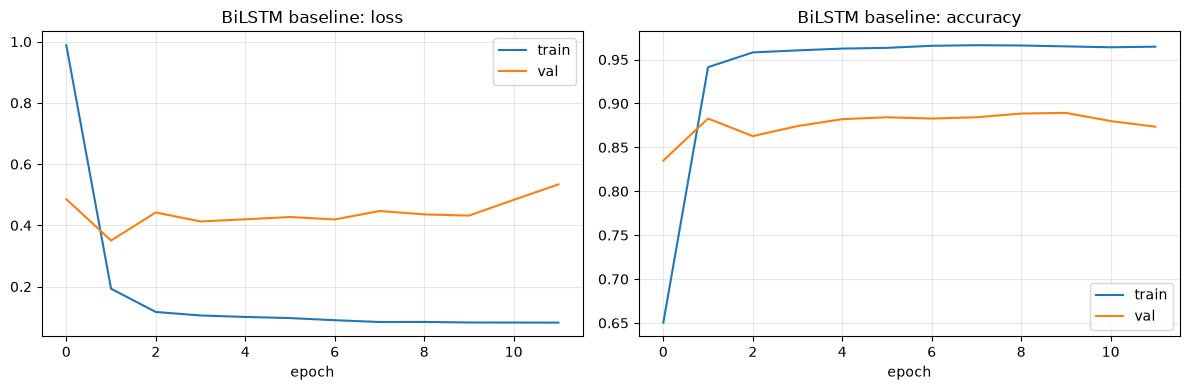

{'epochs_trained': 12, 'best_val_loss_epoch': 2, 'best_val_loss': 0.3504789173603058, 'val_accuracy_at_best_epoch': 0.8828571438789368, 'duration_seconds': 100.32, 'seconds_per_epoch': 8.36, 'total_parameters': 145350}


In [7]:
def plot_history(run_dir, title):
    hist = json.load(open(Path(run_dir) / "history.json"))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(hist["loss"], label="train")
    axes[0].plot(hist["val_loss"], label="val")
    axes[0].set_title(f"{title}: loss")
    axes[1].plot(hist["accuracy"], label="train")
    axes[1].plot(hist["val_accuracy"], label="val")
    axes[1].set_title(f"{title}: accuracy")
    for ax in axes:
        ax.set_xlabel("epoch")
        ax.legend()
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_history(baseline_dir, "BiLSTM baseline")
print({k: baseline_meta[k] for k in ["epochs_trained", "best_val_loss_epoch", "best_val_loss",
                                      "val_accuracy_at_best_epoch", "duration_seconds",
                                      "seconds_per_epoch", "total_parameters"]})

### 5. Hyperparameter tuning (validation split only)
Each variant changes **one** hyperparameter from the baseline, so any difference can be attributed to that change. Every variant uses the same data, seed, epoch budget and callbacks. Variants are ranked by **best validation loss**, with validation accuracy at that epoch reported alongside. The test split is not used here.

| Variant | Change from baseline |
| :--- | :--- |
| baseline | 64 units, 2 layers, lr 5e-4 |
| units_32 | 32 units per direction |
| layers_1 | 1 bidirectional layer |
| lr_1e-3 | learning rate 1e-3 |

In [8]:
import copy

VARIANTS = {
    "units_32": {"model": {"lstm_units": 32}},
    "layers_1": {"model": {"n_layers": 1}},
    "lr_1e-3": {"training": {"learning_rate": 0.001}},
}

tuning_runs = {"baseline": (baseline_meta, baseline_dir)}
for name, overrides in VARIANTS.items():
    cfg = copy.deepcopy(config)
    for section, values in overrides.items():
        cfg[section].update(values)
    cfg["output"]["base_dir"] = "outputs/bilstm/tuning"
    print(f"\n===== Variant: {name} {overrides} =====")
    _, meta, run_dir = train_bilstm_pipeline(cfg, data=data, verbose=0)
    tuning_runs[name] = (meta, run_dir)


===== Variant: units_32 {'model': {'lstm_units': 32}} =====
[Data Contract] Validated successfully.
  Train windows: 5952 (Subjects: [1, 5, 6, 7, 8, 11, 14, 15, 17, 19, 21, 25, 26, 27, 28, 29, 30])
  Val windows:   1400 (Subjects: [3, 16, 22, 23])
  Input window shape: (128, 9)
[Model Architecture] Built 'har_bilstm_classifier'
  Total parameters:     40,134
  Trainable parameters: 40,134
[Training] Starting training: epochs=60, batch_size=64, lr=0.0005...



[Run Completed] Duration: 59.96s | Best Val Loss: 0.4233700931072235 (Epoch 2)
  Artifacts saved to: outputs/bilstm/tuning\run_20260924_111945
  - Model:     outputs/bilstm/tuning\run_20260924_111945\best_model.keras
  - History:   outputs/bilstm/tuning\run_20260924_111945\history.json, outputs/bilstm/tuning\run_20260924_111945\history.csv
  - Metadata:  outputs/bilstm/tuning\run_20260924_111945\run_metadata.json

===== Variant: layers_1 {'model': {'n_layers': 1}} =====
[Data Contract] Validated successfully.
  Train windows: 5952 (Subjects: [1, 5, 6, 7, 8, 11, 14, 15, 17, 19, 21, 25, 26, 27, 28, 29, 30])
  Val windows:   1400 (Subjects: [3, 16, 22, 23])
  Input window shape: (128, 9)
[Model Architecture] Built 'har_bilstm_classifier'
  Total parameters:     46,534
  Trainable parameters: 46,534
[Training] Starting training: epochs=60, batch_size=64, lr=0.0005...



[Run Completed] Duration: 73.54s | Best Val Loss: 0.37372878193855286 (Epoch 5)
  Artifacts saved to: outputs/bilstm/tuning\run_20260924_112045
  - Model:     outputs/bilstm/tuning\run_20260924_112045\best_model.keras
  - History:   outputs/bilstm/tuning\run_20260924_112045\history.json, outputs/bilstm/tuning\run_20260924_112045\history.csv
  - Metadata:  outputs/bilstm/tuning\run_20260924_112045\run_metadata.json

===== Variant: lr_1e-3 {'training': {'learning_rate': 0.001}} =====
[Data Contract] Validated successfully.
  Train windows: 5952 (Subjects: [1, 5, 6, 7, 8, 11, 14, 15, 17, 19, 21, 25, 26, 27, 28, 29, 30])
  Val windows:   1400 (Subjects: [3, 16, 22, 23])
  Input window shape: (128, 9)
[Model Architecture] Built 'har_bilstm_classifier'
  Total parameters:     145,350
  Trainable parameters: 145,350
[Training] Starting training: epochs=60, batch_size=64, lr=0.001...



[Run Completed] Duration: 118.97s | Best Val Loss: 0.33028051257133484 (Epoch 4)
  Artifacts saved to: outputs/bilstm/tuning\run_20260924_112159
  - Model:     outputs/bilstm/tuning\run_20260924_112159\best_model.keras
  - History:   outputs/bilstm/tuning\run_20260924_112159\history.json, outputs/bilstm/tuning\run_20260924_112159\history.csv
  - Metadata:  outputs/bilstm/tuning\run_20260924_112159\run_metadata.json


In [9]:
rows = []
for name, (meta, run_dir) in tuning_runs.items():
    cfg = json.load(open(Path(run_dir) / "config.json"))
    rows.append({
        "variant": name,
        "lstm_units": cfg["model"]["lstm_units"],
        "n_layers": cfg["model"]["n_layers"],
        "learning_rate": cfg["training"]["learning_rate"],
        "params": meta["total_parameters"],
        "best_val_loss": round(meta["best_val_loss"], 4),
        "val_acc_at_best": round(meta["val_accuracy_at_best_epoch"], 4),
        "best_epoch": meta["best_val_loss_epoch"],
        "sec_per_epoch": meta["seconds_per_epoch"],
        "run_dir": run_dir,
    })

tuning_df = pd.DataFrame(rows).sort_values("best_val_loss").reset_index(drop=True)
print(tuning_df.drop(columns="run_dir").to_string(index=False))

CHOSEN = tuning_df.iloc[0]
print(f"\nChosen variant (lowest validation loss): {CHOSEN['variant']}  ->  {CHOSEN['run_dir']}")

 variant  lstm_units  n_layers  learning_rate  params  best_val_loss  val_acc_at_best  best_epoch  sec_per_epoch
 lr_1e-3          64         2         0.0010  145350         0.3303           0.8957           4           8.50
baseline          64         2         0.0005  145350         0.3505           0.8829           2           8.36
layers_1          64         1         0.0005   46534         0.3737           0.8757           5           4.90
units_32          32         2         0.0005   40134         0.4234           0.8750           2           5.00

Chosen variant (lowest validation loss): lr_1e-3  ->  outputs/bilstm/tuning\run_20260924_112159


**Tuning results and choice.**

| Variant | Units | Layers | LR | Params | Best val loss | Val acc at best epoch | Best epoch | s/epoch (CPU) |
| :--- | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| **lr_1e-3** | 64 | 2 | 1e-3 | 145,350 | **0.3303** | **0.8957** | 4 | 8.5 |
| baseline | 64 | 2 | 5e-4 | 145,350 | 0.3505 | 0.8829 | 2 | 8.4 |
| layers_1 | 64 | 1 | 5e-4 | 46,534 | 0.3737 | 0.8757 | 5 | 4.9 |
| units_32 | 32 | 2 | 5e-4 | 40,134 | 0.4234 | 0.8750 | 2 | 5.0 |

**Chosen: `lr_1e-3`** (64 units, 2 layers, learning rate 1e-3). It had the lowest validation loss and the highest validation accuracy. Capacity mattered: halving the units or dropping the second layer cut the parameters by about 70% but also lowered validation accuracy by about 1 point, so the stacked 64-unit model is worth its cost. The higher learning rate helped a little. With `clipnorm=1.0` and ReduceLROnPlateau in place, lr 1e-3 stayed stable and reached a better minimum than 5e-4, which stopped improving after epoch 2. All four variants are within about 2 points of each other. That spread is close to the noise you would expect from 4 validation subjects, so the choice is a modest preference, not a large win. `configs/bilstm.json` keeps the specified baseline (lr 5e-4); pass `--lr 0.001` to reproduce the chosen run.

### 6. Final test evaluation (run once)
The chosen model's best checkpoint is evaluated on the held-out test split, which contains 9 subjects the model has never seen. This is the only cell that reads `X_test`.

In [10]:
final_model = load_bilstm_model(str(Path(CHOSEN["run_dir"]) / "best_model.keras"))

X_test, y_test = data["X_test"], data["y_test"]
test_probs = predict_bilstm(final_model, X_test)
test_pred = np.argmax(test_probs, axis=-1)

test_metrics = {
    "variant": CHOSEN["variant"],
    "run_dir": CHOSEN["run_dir"],
    "test_accuracy": float(accuracy_score(y_test, test_pred)),
    "test_macro_f1": float(f1_score(y_test, test_pred, average="macro")),
    "test_weighted_f1": float(f1_score(y_test, test_pred, average="weighted")),
    "num_test_samples": int(len(y_test)),
    "test_subjects": sorted(int(s) for s in np.unique(data["subject_test"])),
}
print(json.dumps({k: v for k, v in test_metrics.items() if k != "test_subjects"}, indent=2))
print()
print(classification_report(y_test, test_pred, target_names=CLASS_NAMES, digits=4))

{
  "variant": "lr_1e-3",
  "run_dir": "outputs/bilstm/tuning\\run_20260924_112159",
  "test_accuracy": 0.8982015609093994,
  "test_macro_f1": 0.897360242465063,
  "test_weighted_f1": 0.8978074458177433,
  "num_test_samples": 2947
}

                    precision    recall  f1-score   support

           WALKING     0.9004    0.8931    0.8968       496
  WALKING_UPSTAIRS     0.9702    0.8981    0.9327       471
WALKING_DOWNSTAIRS     0.8636    0.9500    0.9048       420
           SITTING     0.8756    0.7454    0.8053       491
          STANDING     0.7970    0.9004    0.8455       532
            LAYING     0.9981    1.0000    0.9991       537

          accuracy                         0.8982      2947
         macro avg     0.9008    0.8978    0.8974      2947
      weighted avg     0.9013    0.8982    0.8978      2947



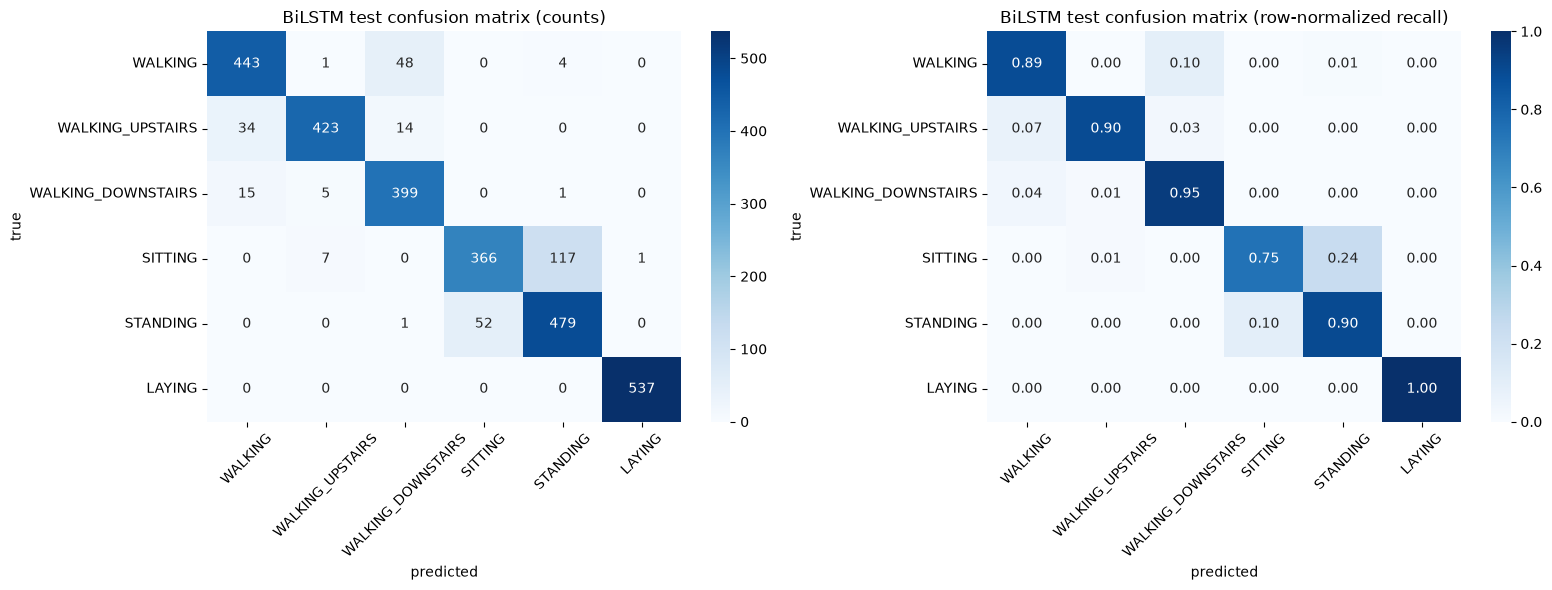

             SITTING -> STANDING             117
            STANDING -> SITTING              52
             WALKING -> WALKING_DOWNSTAIRS   48
    WALKING_UPSTAIRS -> WALKING              34
  WALKING_DOWNSTAIRS -> WALKING              15


In [11]:
cm = confusion_matrix(y_test, test_pred)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title("BiLSTM test confusion matrix (counts)")
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title("BiLSTM test confusion matrix (row-normalized recall)")
for ax in axes:
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# Largest off-diagonal confusions
off_diag = [(CLASS_NAMES[i], CLASS_NAMES[j], int(cm[i, j])) for i in range(6) for j in range(6) if i != j and cm[i, j] > 0]
for true_c, pred_c, n in sorted(off_diag, key=lambda t: -t[2])[:5]:
    print(f"{true_c:>20} -> {pred_c:<20} {n}")

### 7. Save the model and metrics
The metrics, tuning table and confusion matrix are saved next to the chosen model. Member 4's shared evaluation can then pick them up without re-running this notebook.

In [12]:
chosen_dir = Path(CHOSEN["run_dir"])
test_metrics["confusion_matrix"] = cm.tolist()
test_metrics["class_names"] = CLASS_NAMES

with open(chosen_dir / "test_metrics.json", "w", encoding="utf-8") as f:
    json.dump(test_metrics, f, indent=2)
tuning_df.to_csv(chosen_dir / "tuning_results.csv", index=False)
fig.savefig(chosen_dir / "confusion_matrix.png", dpi=150, bbox_inches="tight")

print("Saved to", chosen_dir)
for p in sorted(chosen_dir.iterdir()):
    print("  -", p.name)

Saved to outputs\bilstm\tuning\run_20260924_112159
  - best_model.keras
  - config.json
  - confusion_matrix.png
  - history.csv
  - history.json
  - run_metadata.json
  - test_metrics.json
  - tuning_results.csv


### 8. Observations

- **Convergence speed.** The BiLSTM converges very quickly. Validation accuracy passes 83% after one epoch, and the best validation loss comes at epoch 2–5 for every variant. Early stopping (patience 10) then ends each run after 12–15 epochs, which is about 1.5–2 minutes on CPU at roughly 8.5 s per epoch for the 2-layer model. The recurrence over 128 steps has to run sequentially, so each epoch costs more than a convolutional model of similar size would.
- **Training stability.** With gradient clipping (`clipnorm=1.0`) the loss never spiked or went NaN, even at lr 1e-3. ReduceLROnPlateau halved the learning rate once validation loss stalled.
- **Overfitting evidence.** Training accuracy keeps climbing to about 96–97%, while validation accuracy plateaus at about 88–90% and validation loss drifts upward after its minimum. That gap of about 7 points is a subject gap: the validation windows come from 4 people the model has never seen. Restoring the best weights from early stopping is therefore essential.
- **Test result.** The chosen model reaches **89.8% test accuracy and 0.897 macro F1** on the 9 held-out test subjects. This is in line with its validation accuracy (89.6%), which suggests the subject-wise validation split was a faithful proxy for the test set.
- **Confused classes.** The largest error by far is **SITTING predicted as STANDING (117 of 491 sitting windows, 74.5% recall)**, plus 52 STANDING windows predicted as SITTING. A waist-mounted phone sees an almost identical gravity vector in both postures, and neither posture involves motion that the LSTM can use. The dynamic classes are confused mostly with each other (WALKING predicted as WALKING_DOWNSTAIRS: 48; WALKING_UPSTAIRS predicted as WALKING: 34). LAYING is perfect (537/537), because gravity lies on a different axis.